/var/folders/nt/998zzxpj2632htnn_h4jz6n40000gn/T/ipykernel_31325/4002038197.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


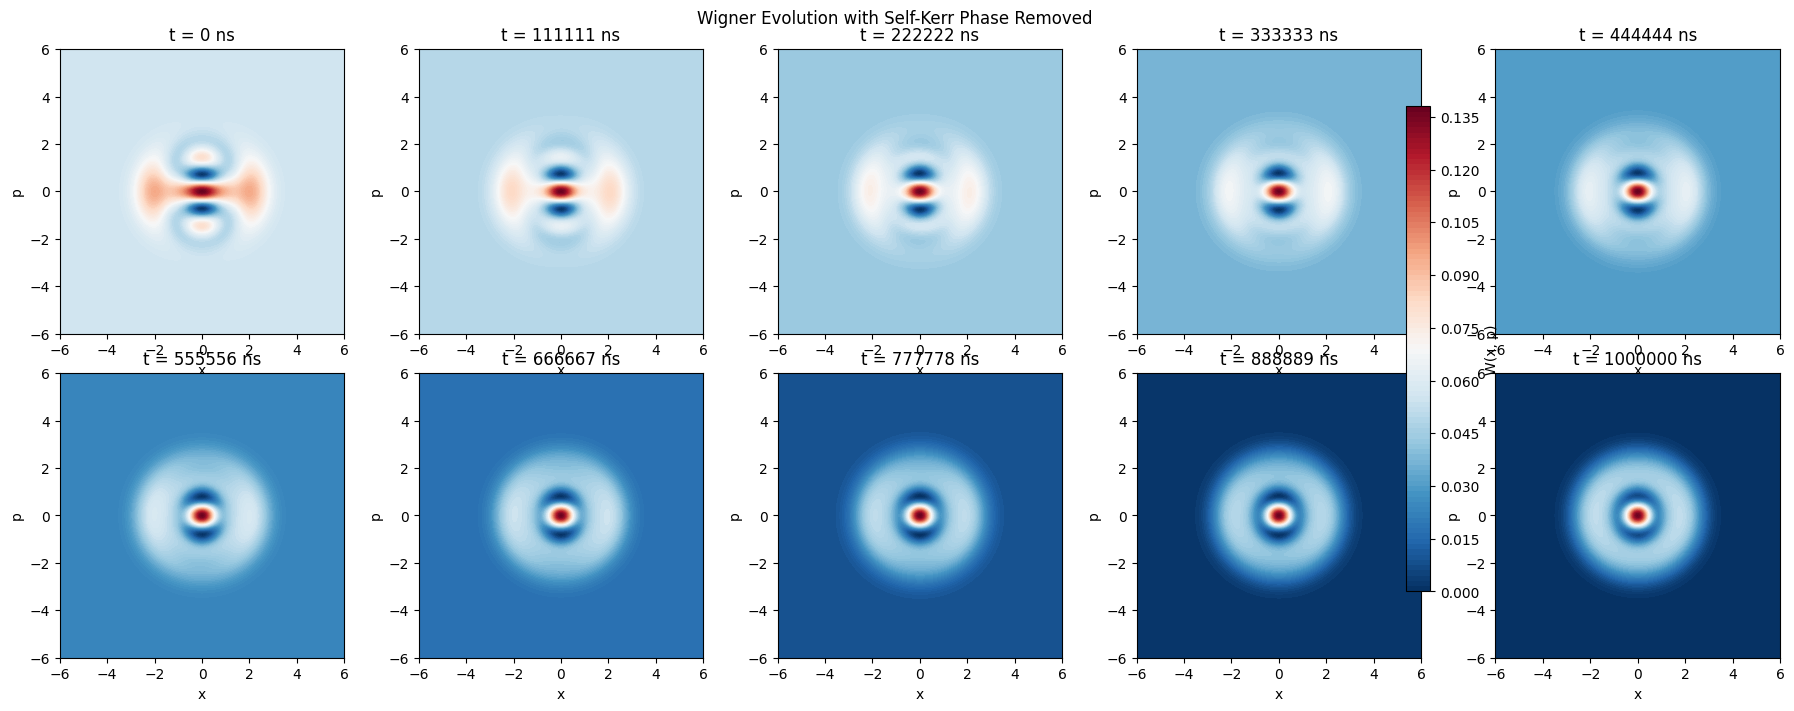

In [73]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- 1. Parameters ---
N = 5               # Truncate Hilbert space at 7
omega = 0 * np.pi * 5.0 # Cavity frequency (arbitrary)
gamma_true = 0.25e-6       # Decay rate in ns^-1

t_max = 1e6         # Simulation time in ns
tlist = np.linspace(0, t_max, int(t_max))

# Drive parameters (angular frequency units)
Omega_d = 2 * np.pi * 0.02    # drive amplitude
omega_d = omega                # resonant drive

# --- 2. Setup Operators & Initial State ---
c = qt.destroy(N)
H0 = 0.05**4*0.1*2*np.pi*c.dag()*c.dag()*c*c
Hd = c + c.dag()
H = [H0]
args = {'Omega_d': Omega_d, 'omega_d': omega_d}

# Logical-state style initialization using Fock states (single-mode analog)
ket0 = qt.basis(N, 0)
ket2 = qt.basis(N, 2)
ket4 = qt.basis(N, 4)
ket0L = (ket0 + ket4).unit()
ket1L = ket2
psi_vec = (ket0L + ket1L).unit()
rho0 = qt.ket2dm(psi_vec)

n_op = c.dag() * c
c_ops = [
    np.sqrt(gamma_true) * c,
    np.sqrt(1e-5/8) * n_op,  # pure dephasing channel
]
e_ops = [qt.fock_dm(N, 4), qt.fock_dm(N, 3), qt.fock_dm(N, 2), qt.fock_dm(N, 1)]

# --- 3. Run Lindblad simulation, then remove self-Kerr phase ---
opts = qt.Options(atol=1e-10, rtol=1e-10)
result = qt.mesolve(H, rho0, tlist, c_ops, e_ops=None, args=args, options=opts)

# Density matrices in the lab frame from mesolve
rho_lab_states = result.states

# Go to interaction frame of H0 to eliminate cavity phase from self-Kerr
# rho_I(t) = exp(+i H0 t) rho_lab(t) exp(-i H0 t)
def remove_self_kerr_phase(rho_t, t, H_kerr):
    U_t = (1j * H_kerr * t).expm()
    return U_t * rho_t * U_t.dag()

rho_kerr_free_states = [remove_self_kerr_phase(rho_t, t, H0) for rho_t, t in zip(rho_lab_states, tlist)]

# Example: grab any transformed density matrix by index
rho_t_example = rho_kerr_free_states[0]

# Choose 10 uniformly sampled snapshot times (including t=0 and t=t_max)
sample_times = np.linspace(0, t_max, 10)
sample_indices = [int(np.argmin(np.abs(tlist - ts))) for ts in sample_times]

# Phase-space grid
xvec = np.linspace(-6, 6, 201)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, idx, ts in zip(axes.flat, sample_indices, sample_times):
    rho_t = rho_kerr_free_states[idx]
    W = qt.wigner(rho_t, xvec, xvec)
    im = ax.contourf(xvec, xvec, W, 120, cmap='RdBu_r')
    ax.set_title(f't = {ts:.0f} ns')
    ax.set_xlabel('x')
    ax.set_ylabel('p')
    ax.set_aspect('equal')

fig.suptitle('Wigner Evolution with Self-Kerr Phase Removed')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9, label='W(x, p)')
plt.tight_layout()
plt.show()

--- Extracted Raw Transition Rates (Gamma_n) ---
Extracted Rate out of |4> (Gamma_4): 1.000e-06
Extracted Rate out of |3> (Gamma_3): 2.164e-06
Extracted Rate out of |2> (Gamma_2): 9.177e-06
Extracted Rate out of |1> (Gamma_1): 2.025e-05


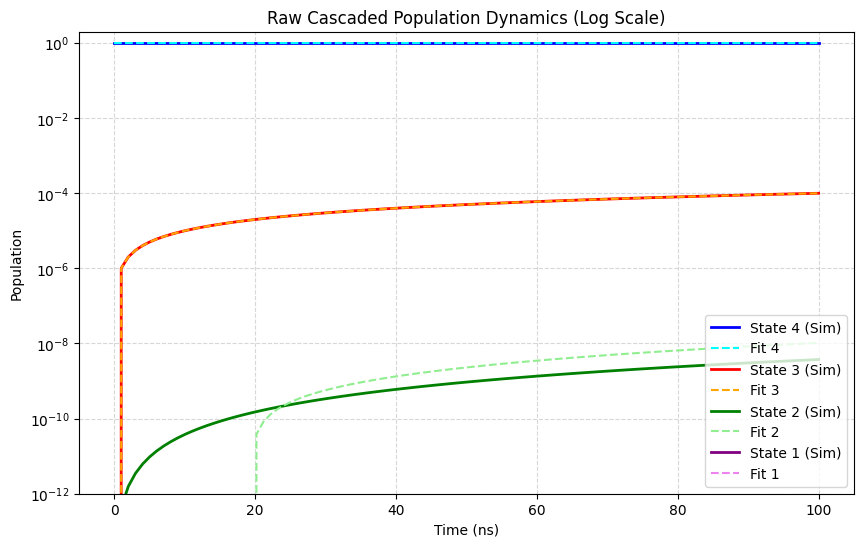

In [34]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- 1. Parameters ---
N = 15                  # Truncate Hilbert space at 7
omega = 2 * np.pi * 5.0 # Cavity frequency (arbitrary)
gamma_true = 0.25e-6       # Decay rate in ns^-1

t_max = 1e2             # Simulation time in ns
tlist = np.linspace(0, t_max, int(t_max))

# Drive parameters (angular frequency units)
Omega_d = 2 * np.pi * 0.02    # drive amplitude
omega_d = omega                # resonant drive

# --- 2. Setup Operators & Initial State ---
c = qt.destroy(N)
H0 = omega * c.dag() * c
Hd = c + c.dag()
H = [H0]
args = {'Omega_d': Omega_d, 'omega_d': omega_d}


rho0 = qt.basis(N, 4)

c_ops = [np.sqrt(gamma_true) * c]
e_ops = [qt.fock_dm(N, 4), qt.fock_dm(N, 3), qt.fock_dm(N, 2), qt.fock_dm(N, 1)]

# --- 3. Run Lindblad Simulation (with tight tolerances) ---
# Added tight tolerances to fix the numerical error on State 1 at small populations
opts = qt.Options(atol=1e-6, rtol=1e-6)
result = qt.mesolve(H, rho0, tlist, c_ops, e_ops=e_ops, args=args, options=opts)

P4_sim = result.expect[0]
P3_sim = result.expect[1]
P2_sim = result.expect[2]
P1_sim = result.expect[3]

# --- 4. Generic Cascaded Fitting Functions (Bateman Equations) ---
# These functions make zero assumptions about the physical n*gamma rule.
# eps is added to prevent division-by-zero during optimizer guesswork.
eps = 1e-15 

def pop_4_raw(t, L4): 
    return np.exp(-L4 * t)

def pop_3_raw(t, L4, L3):
    return L4 * (np.exp(-L4 * t) / (L3 - L4 + eps) + np.exp(-L3 * t) / (L4 - L3 + eps))

def pop_2_raw(t, L4, L3, L2):
    d1 = (L3 - L4 + eps) * (L2 - L4 + eps)
    d2 = (L4 - L3 + eps) * (L2 - L3 + eps)
    d3 = (L4 - L2 + eps) * (L3 - L2 + eps)
    return L4 * L3 * (np.exp(-L4 * t) / d1 + np.exp(-L3 * t) / d2 + np.exp(-L2 * t) / d3)

def pop_1_raw(t, L4, L3, L2, L1):
    d1 = (L3 - L4 + eps) * (L2 - L4 + eps) * (L1 - L4 + eps)
    d2 = (L4 - L3 + eps) * (L2 - L3 + eps) * (L1 - L3 + eps)
    d3 = (L4 - L2 + eps) * (L3 - L2 + eps) * (L1 - L2 + eps)
    d4 = (L4 - L1 + eps) * (L3 - L1 + eps) * (L2 - L1 + eps)
    return L4 * L3 * L2 * (np.exp(-L4 * t) / d1 + np.exp(-L3 * t) / d2 + np.exp(-L2 * t) / d3 + np.exp(-L1 * t) / d4)

# --- 5. Perform Curve Fitting (Sequential) ---
# We fit state 4 first, then use that extracted rate to help fit state 3, and so on.
# This prevents the optimizer from getting confused by too many free variables.
g4, _ = curve_fit(pop_4_raw, tlist, P4_sim, p0=[1e-5])
L4 = g4[0]

g3, _ = curve_fit(lambda t, L3: pop_3_raw(t, L4, L3), tlist, P3_sim, p0=[1e-5])
L3 = g3[0]

g2, _ = curve_fit(lambda t, L2: pop_2_raw(t, L4, L3, L2), tlist, P2_sim, p0=[1e-5])
L2 = g2[0]

g1, _ = curve_fit(lambda t, L1: pop_1_raw(t, L4, L3, L2, L1), tlist, P1_sim, p0=[1e-5])
L1 = g1[0]

print(f"--- Extracted Raw Transition Rates (Gamma_n) ---")
print(f"Extracted Rate out of |4> (Gamma_4): {L4:.3e}")
print(f"Extracted Rate out of |3> (Gamma_3): {L3:.3e}")
print(f"Extracted Rate out of |2> (Gamma_2): {L2:.3e}")
print(f"Extracted Rate out of |1> (Gamma_1): {L1:.3e}")

# --- 6. Plotting (Log Scale) ---
plt.figure(figsize=(10, 6))

plt.semilogy(tlist, P4_sim, label='State 4 (Sim)', color='blue', lw=2)
plt.semilogy(tlist, pop_4_raw(tlist, L4), '--', label='Fit 4', color='cyan')

plt.semilogy(tlist, P3_sim, label='State 3 (Sim)', color='red', lw=2)
plt.semilogy(tlist, pop_3_raw(tlist, L4, L3), '--', label='Fit 3', color='orange')

plt.semilogy(tlist, P2_sim, label='State 2 (Sim)', color='green', lw=2)
plt.semilogy(tlist, pop_2_raw(tlist, L4, L3, L2), '--', label='Fit 2', color='lightgreen')

plt.semilogy(tlist, P1_sim, label='State 1 (Sim)', color='purple', lw=2)
plt.semilogy(tlist, pop_1_raw(tlist, L4, L3, L2, L1), '--', label='Fit 1', color='violet')

plt.xlabel('Time (ns)')
plt.ylabel('Population')
plt.title('Raw Cascaded Population Dynamics (Log Scale)')
plt.ylim(1e-12, 2) 
plt.legend(loc='lower right')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/fluxonium/lib/python3.11/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


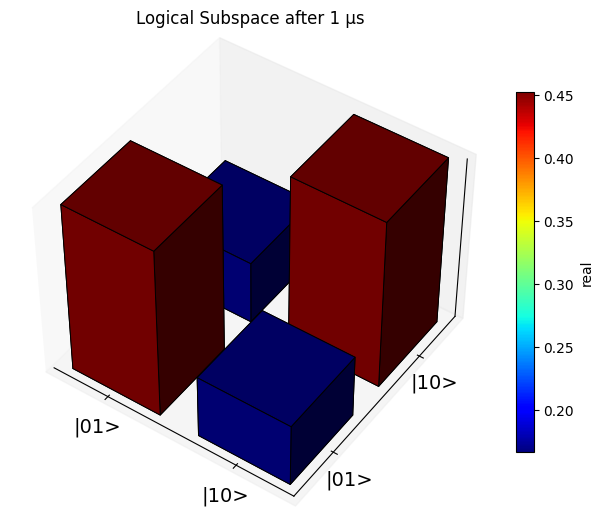

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, tensor, sigmam, sigmaz, qeye, mesolve, matrix_histogram, Qobj

# 1. Physical Parameters
t1_both = 1e6      # Relaxation for both modes (1 microsecond)
t_phi_10 = 1e5     # Pure dephasing for the |10> state (10 microseconds)
sim_time = 1e5     # We will simulate exactly 1 microsecond

# 2. Calculate continuous decay rates
gamma_1 = 1.0 / t1_both
gamma_phi = 1.0 / t_phi_10

# 3. Define the Operators for a 2-qubit (4-level) system
# Identity operator for the inactive mode
I = qeye(2)

# Collapse operators
# Relaxation: sigmam() applied to qubit 0 (left) and qubit 1 (right)
c_relax_q0 = np.sqrt(gamma_1) * tensor(sigmam(), I) 
c_relax_q1 = np.sqrt(gamma_1) * tensor(I, sigmam())

# Pure dephasing: sigmaz() applied ONLY to qubit 0 (which makes up the '1' in |10>)
c_dephase_q0 = np.sqrt(gamma_phi / 2) * tensor(sigmaz(), I)

c_ops = [c_relax_q0, c_relax_q1, c_dephase_q0]

# 4. Define the Initial Logical State: A pure |+>_L superposition
# |0>_L = |01> and |1>_L = |10>
logical_0 = tensor(basis(2, 0), basis(2, 1))  # |0> x |1> = |01>
logical_1 = tensor(basis(2, 1), basis(2, 0))  # |1> x |0> = |10>

psi0 = (logical_0 + logical_1).unit()
H = 0 * tensor(sigmaz(), sigmaz()) # No Hamiltonian dynamics, just noise

# 5. Run the Master Equation Solver
tlist = np.linspace(0, sim_time, 100)
result = mesolve(H, psi0, tlist, c_ops, [])

# 6. Extract the Final 4x4 Density Matrix
rho_full = result.states[-1].full()

# 7. Project into the Logical Subspace
# In a standard tensor product basis:
# Index 1 corresponds to |01>
# Index 2 corresponds to |10>
rho_logical_array = np.zeros((2, 2), dtype=complex)
rho_logical_array[0, 0] = rho_full[1, 1]  # <01|rho|01>
rho_logical_array[0, 1] = rho_full[1, 2]  # <01|rho|10>
rho_logical_array[1, 0] = rho_full[2, 1]  # <10|rho|01>
rho_logical_array[1, 1] = rho_full[2, 2]  # <10|rho|10>

# Convert back to a QuTiP quantum object for plotting
rho_logical = Qobj(rho_logical_array)

# 8. Plot the Subspace Cityscape

fig, ax = matrix_histogram(rho_logical, ['|01>', '|10>'], ['|01>', '|10>'])
ax.set_title("Logical Subspace after 1 μs")
ax.view_init(azim=-55, elev=45) 
plt.show()